# Hurricane Milton (2024) — AI Model Track Comparison

Compare tropical cyclone tracks from **AIFS** and **GraphCast**
against ERA5 reanalysis for Hurricane Milton, at three lead times before
landfall (T−72 h, T−168 h, T−240 h).

**Verification target:** Milton's Florida Gulf Coast landfall (Siesta Key),
snapped to `2024-10-10 00:00 UTC`.

| Lead | Init time (UTC)  | Steps (6 h) |
|------|------------------|-------------|
| 72 h | 2024-10-07 00:00 | 12          |
| 168 h| 2024-10-03 00:00 | 28          |
| 240 h| 2024-09-30 00:00 | 40          |

In [1]:
import os

# Must be set BEFORE importing torch.
os.environ["FORCE_CUDA_EXTENSION"] = "1"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
os.environ["CUDA_HOME"] = "/usr/local/cuda"
os.environ["EARTH2STUDIO_CACHE"] = os.path.expanduser("~/.cache/earth2studio")
os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"
# Prevent JAX from pre-allocating all GPU memory (needed for GraphCast + PyTorch coexistence).
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

for k in ["FORCE_CUDA_EXTENSION", "TORCH_CUDA_ARCH_LIST", "CUDA_HOME", "EARTH2STUDIO_CACHE"]:
    print(f"  {k} = {os.environ[k]}")
print("DONE")

  FORCE_CUDA_EXTENSION = 1
  TORCH_CUDA_ARCH_LIST = 8.9
  CUDA_HOME = /usr/local/cuda
  EARTH2STUDIO_CACHE = /home/jovyan/.cache/earth2studio
DONE

In [2]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import torch
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

from earth2studio.models.px import AIFS, GraphCastOperational
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import ARCO, CDS, fetch_data, prep_data_array
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("Done")

/home/jovyan/hurricane-forecasts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead. parsing error, invalid json config /dev/null
 failed to load user config: /dev/null Invalid argument
 cuFile configuration load error
 cuFile initialization failed
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this featureDevice: cuda
GPU   : NVIDIA L40
VRAM  : 47.7 GB
Done

In [3]:
# ── Storm & experiment configuration ──────────────────────────────────
STORM_NAME = "Milton"

# Landfall snapped to nearest 6h boundary.
VERIFICATION_TIME = datetime(2024, 10, 10, 0)

# Lead times in hours before VERIFICATION_TIME.
LEAD_TIMES_H = [72, 168, 240]

# Derived: init time and step count for each lead.
INIT_TIMES = {h: VERIFICATION_TIME - timedelta(hours=h) for h in LEAD_TIMES_H}
N_STEPS    = {h: h // 6 for h in LEAD_TIMES_H}

# Output directory — all .pt track files and plots go here.
OUT_DIR = Path("./outputs/milton")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot extent (lon_min, lon_max, lat_min, lat_max).
PLOT_EXTENT = (-100, -65, 15, 40)

# Landfall point: Siesta Key, FL.
LANDFALL_LAT = 27.3
LANDFALL_LON = -82.5

MODEL_COLORS = {
    "AIFS":      "#2ca02c",  # green
    "GraphCast": "#1f77b4",  # blue
    "ERA5":      "#000000",  # black (reanalysis truth)
}

for h in LEAD_TIMES_H:
    print(f"  T-{h:>3}h : init={INIT_TIMES[h]}  steps={N_STEPS[h]}")

  T- 72h : init=2024-10-07 00:00:00  steps=12
  T-168h : init=2024-10-03 00:00:00  steps=28
  T-240h : init=2024-09-30 00:00:00  steps=40

## Helper functions

`TCTrackerWuDuan` runs **during** inference. At each 6 h autoregressive step the
model state is passed to the tracker, which updates its path buffer. Output shape:
`(batch, num_paths, time_steps, 4)` — `[tc_lat, tc_lon, tc_msl, tc_w10m]`.

In [4]:
def run_tc_inference(prognostic, data_source, start_time, nsteps, save_path):
    """Run a prognostic model through TCTrackerWuDuan and save tracks."""
    if Path(save_path).exists():
        print(f"  cached \u2192 {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    prognostic = prognostic.to(DEVICE)
    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  \u2192 {save_path}")
    return tracks

In [5]:
def run_era5_truth(data_source, start_time, nsteps, save_path):
    """Track ERA5 reanalysis through TCTrackerWuDuan step-by-step."""
    if Path(save_path).exists():
        print(f"  cached \u2192 {save_path}")
        return torch.load(str(save_path), map_location="cpu")

    tracker = TCTrackerWuDuan()
    tracker.reset_path_buffer()

    times = [start_time + timedelta(hours=6 * i) for i in range(nsteps + 1)]
    for step, time in tqdm(enumerate(times), total=len(times)):
        da = data_source(time, tracker.input_coords()["variable"])
        x, coords = prep_data_array(da, device=DEVICE)
        output, _ = tracker(x, coords)

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"  saved  \u2192 {save_path}")
    return tracks

In [6]:
# ARCO ERA5 — used for FCN3/ERA5 truth (atmospheric vars only).
data_source = ARCO(cache=True)

In [7]:
# CDS ERA5 — required for AIFS (needs soil moisture/temperature vars not in ARCO).
aifs_data_source = CDS(cache=True)

## AIFS forecasts

AIFS (ECMWF) — GNN encoder + sliding-window transformer processor.
First ML model fully operational at a major NWP center (Feb 2025).

In [8]:
%%time
aifs = AIFS.load_model(AIFS.load_default_package())

CPU times: user 5.51 s, sys: 545 ms, total: 6.05 s
Wall time: 6 s

In [10]:
%%time
aifs_tracks_72 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "aifs_72h.pt",
)

  cached → outputs/milton/aifs_72h.pt
CPU times: user 1.52 ms, sys: 36 μs, total: 1.55 ms
Wall time: 1.1 ms

In [12]:
#%%time
aifs_tracks_168 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "aifs_168h.pt",
)

  cached → outputs/milton/aifs_168h.pt

In [11]:
%%time
aifs_tracks_240 = run_tc_inference(
    aifs, aifs_data_source,
    INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "aifs_240h.pt",
)

2026-05-19 20:18:22.379 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2024-09-29 18:00:00 with 1 levels
2026-05-19 20:18:22.379 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2024-09-29 18:00:00 with 1 levels
2026-05-19 20:18:22.379 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2024-09-29 18:00:00 with 1 levels
2026-05-19 20:18:22.379 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_temperature at 2024-09-29 18:00:00 with 1 levels
2026-05-19 20:18:22.379 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2024-09-29 18:00:00 with 1 levels
2026-05-19 20:18:22.380 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: sp

2026-05-19 20:18:28.014 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2024-09-30 00:00:00 with 1 levels
2026-05-19 20:18:28.015 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2024-09-30 00:00:00 with 1 levels
2026-05-19 20:18:28.015 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2024-09-30 00:00:00 with 1 levels
2026-05-19 20:18:28.029 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_temperature at 2024-09-30 00:00:00 with 1 levels
2026-05-19 20:18:28.030 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2024-09-30 00:00:00 with 1 levels
2026-05-19 20:18:28.030 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: sp

  0%|                                                                                                            | 0/41 [00:00<?, ?it/s]

  2%|██▍                                                                                                 | 1/41 [00:00<00:05,  7.08it/s]

  5%|████▉                                                                                               | 2/41 [00:01<00:22,  1.73it/s]

...

 93%|███████████████████████████████████████████████████████████████████████████████████████████▊       | 38/41 [00:30<00:02,  1.24it/s]

 95%|██████████████████████████████████████████████████████████████████████████████████████████████▏    | 39/41 [00:31<00:01,  1.24it/s]

 98%|████████████████████████████████████████████████████████████████████████████████████████████████▌  | 40/41 [00:32<00:00,  1.24it/s]

 98%|████████████████████████████████████████████████████████████████████████████████████████████████▌  | 40/41 [00:32<00:00,  1.22it/s]

  saved  → outputs/milton/aifs_240h.pt
CPU times: user 36.3 s, sys: 2.7 s, total: 39 s
Wall time: 46 s


In [12]:
import gc
del aifs
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved


## GraphCast forecasts

GraphCast (Google DeepMind) — autoregressive GNN on an icosahedral multi-mesh.
Uses JAX under the hood; `XLA_PYTHON_CLIENT_PREALLOCATE=false` prevents it from
grabbing all GPU memory before PyTorch can use it.

In [13]:
%%time
graphcast = GraphCastOperational.load_model(GraphCastOperational.load_default_package())

CPU times: user 358 ms, sys: 713 ms, total: 1.07 s
Wall time: 21.2 s


In [14]:
%%time
gc_tracks_72 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "graphcast_72h.pt",
)

2026-05-19 20:19:30.992 | DEBUG    | earth2studio.data.arco:_async_init:125 - Using Multi-Storage Client for ARCO data access


Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:01<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:01<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:01<?, ?it/s]

...

 77%|████████████████████████████████████████████████████████████████████████████▏                      | 10/13 [01:34<00:08,  2.75s/it]

 85%|███████████████████████████████████████████████████████████████████████████████████▊               | 11/13 [01:35<00:04,  2.33s/it]

 92%|███████████████████████████████████████████████████████████████████████████████████████████▍       | 12/13 [01:37<00:02,  2.03s/it]

 92%|███████████████████████████████████████████████████████████████████████████████████████████▍       | 12/13 [01:38<00:08,  8.23s/it]

  saved  → outputs/milton/graphcast_72h.pt
CPU times: user 1min 41s, sys: 18.9 s, total: 2min
Wall time: 2min 2s


In [15]:
%%time
gc_tracks_168 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "graphcast_168h.pt",
)

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:02<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:02<?, ?it/s]

Fetching ARCO data:  10%|████████                                                                        | 1/10 [00:02<00:21,  2.37s/it]

Fetching ARCO data:  10%|████████                                                                        | 1/10 [00:02<00:21,  2.37s/it]

...

 90%|████████████████████████████████████████████████████████████████████████████████████████▊          | 26/29 [00:37<00:04,  1.35s/it]

 93%|████████████████████████████████████████████████████████████████████████████████████████████▏      | 27/29 [00:39<00:02,  1.34s/it]

 97%|███████████████████████████████████████████████████████████████████████████████████████████████▌   | 28/29 [00:40<00:01,  1.35s/it]

 97%|███████████████████████████████████████████████████████████████████████████████████████████████▌   | 28/29 [00:41<00:01,  1.49s/it]

  saved  → outputs/milton/graphcast_168h.pt
CPU times: user 16.6 s, sys: 21.7 s, total: 38.3 s
Wall time: 56.6 s


In [16]:
%%time
gc_tracks_240 = run_tc_inference(
    graphcast, data_source,
    INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "graphcast_240h.pt",
)

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                        | 0/10 [00:00<?, ?it/s]

...

 93%|███████████████████████████████████████████████████████████████████████████████████████████▊       | 38/41 [00:54<00:04,  1.36s/it]

 95%|██████████████████████████████████████████████████████████████████████████████████████████████▏    | 39/41 [00:55<00:02,  1.36s/it]

 98%|████████████████████████████████████████████████████████████████████████████████████████████████▌  | 40/41 [00:56<00:01,  1.36s/it]

 98%|████████████████████████████████████████████████████████████████████████████████████████████████▌  | 40/41 [00:58<00:01,  1.46s/it]

  saved  → outputs/milton/graphcast_240h.pt
CPU times: user 22.9 s, sys: 27.7 s, total: 50.7 s
Wall time: 1min 14s


In [17]:
del graphcast
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved


## ERA5 truth tracks

Run `TCTrackerWuDuan` on ERA5 reanalysis for each lead-time window.
Using the same tracker as the forecasts ensures no confound from different implementations.

In [18]:
%%time
era5_tracks_72 = run_era5_truth(
    data_source, INIT_TIMES[72], N_STEPS[72],
    OUT_DIR / "era5_72h.pt",
)

  0%|                                                                                                            | 0/13 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

Fetching ARCO data:  20%|████████████████▏                                                                | 1/5 [00:00<00:00,  8.41it/s]

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.08it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 11.99it/s]

...

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:02<00:00,  2.23it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.21it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:32<00:00,  2.55s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:32<00:00,  2.46s/it]

  saved  → outputs/milton/era5_72h.pt
CPU times: user 3.7 s, sys: 5.73 s, total: 9.42 s
Wall time: 32 s


In [19]:
%%time
era5_tracks_168 = run_era5_truth(
    data_source, INIT_TIMES[168], N_STEPS[168],
    OUT_DIR / "era5_168h.pt",
)

  0%|                                                                                                            | 0/29 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

Fetching ARCO data:  20%|████████████████▏                                                                | 1/5 [00:00<00:00,  7.25it/s]

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.08it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 11.89it/s]

...

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.09it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 12.03it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:45<00:00,  1.76it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:45<00:00,  1.56s/it]

  saved  → outputs/milton/era5_168h.pt
CPU times: user 8.36 s, sys: 12.2 s, total: 20.5 s
Wall time: 45.2 s


In [20]:
%%time
era5_tracks_240 = run_era5_truth(
    data_source, INIT_TIMES[240], N_STEPS[240],
    OUT_DIR / "era5_240h.pt",
)

  0%|                                                                                                            | 0/41 [00:00<?, ?it/s]

Fetching ARCO data:   0%|                                                                                         | 0/5 [00:00<?, ?it/s]

Fetching ARCO data:  20%|████████████████▏                                                                | 1/5 [00:00<00:00,  8.17it/s]

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00,  9.85it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 12.09it/s]

...

Fetching ARCO data:  80%|████████████████████████████████████████████████████████████████▊                | 4/5 [00:00<00:00, 10.25it/s]

Fetching ARCO data: 100%|█████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 12.22it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:42<00:00,  1.86it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:42<00:00,  1.03s/it]

  saved  → outputs/milton/era5_240h.pt
CPU times: user 11.9 s, sys: 16.3 s, total: 28.2 s
Wall time: 42.1 s


In [21]:
# Reload all .pt files — safe to re-run after a kernel restart.
aifs_tracks_72  = torch.load(OUT_DIR / "aifs_72h.pt",  map_location="cpu")
aifs_tracks_168 = torch.load(OUT_DIR / "aifs_168h.pt", map_location="cpu")
aifs_tracks_240 = torch.load(OUT_DIR / "aifs_240h.pt", map_location="cpu")

era5_tracks_72  = torch.load(OUT_DIR / "era5_72h.pt",  map_location="cpu")
era5_tracks_168 = torch.load(OUT_DIR / "era5_168h.pt", map_location="cpu")
era5_tracks_240 = torch.load(OUT_DIR / "era5_240h.pt", map_location="cpu")

gc_tracks_72  = torch.load(OUT_DIR / "graphcast_72h.pt",  map_location="cpu")
gc_tracks_168 = torch.load(OUT_DIR / "graphcast_168h.pt", map_location="cpu")
gc_tracks_240 = torch.load(OUT_DIR / "graphcast_240h.pt", map_location="cpu")

print(f"AIFS  T-72h : {aifs_tracks_72.shape}")
print(f"ERA5  T-72h : {era5_tracks_72.shape}")
print(f"GCast T-72h : {gc_tracks_72.shape}")

AIFS  T-72h : torch.Size([1, 17, 13, 4])
ERA5  T-72h : torch.Size([1, 21, 13, 4])
GCast T-72h : torch.Size([1, 14, 13, 4])


## Track comparison maps

In [22]:
def plot_tracks(models_list, extent, title, init_time, nsteps, save_path=None):
    """Plot TC tracks on a Cartopy map. ERA5 solid, forecasts dashed; markers sized by 10-m wind."""
    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(11, 7),
    )

    ax.add_feature(cfeature.LAND,      facecolor="#e8e8e8", zorder=1)
    ax.add_feature(cfeature.OCEAN,     facecolor="#d0e8f5", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.STATES,    linewidth=0.3, linestyle=":", edgecolor="0.5", zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, edgecolor="0.4", zorder=3)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    for m in models_list:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        ls = "-"  if m["name"].startswith("ERA5") else "--"
        lw = 2.2  if m["name"].startswith("ERA5") else 1.8
        label_used = False

        for p in range(tracks.shape[1]):
            lats = tracks[0, p, :, 0]
            lons = tracks[0, p, :, 1] - 360.0
            w10m = tracks[0, p, :, 3]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() < 2:
                continue

            idx = np.where(mask)[0]
            lv, lnv, wv = lats[idx], lons[idx], w10m[idx]

            ax.plot(
                lnv, lv, color=m["color"], linewidth=lw, linestyle=ls,
                label=m["name"] if not label_used else "",
                transform=ccrs.PlateCarree(), zorder=5,
            )
            label_used = True

            sizes = np.clip(wv * 3.5, 15, 160)
            ax.scatter(
                lnv, lv, s=sizes, color=m["color"],
                edgecolors="white", linewidths=0.5,
                transform=ccrs.PlateCarree(), zorder=6,
            )

            for i, sz in [(0, 70), (-1, 90)]:
                ax.scatter(
                    lnv[i], lv[i], s=sz,
                    facecolors="none", edgecolors=m["color"], linewidths=1.6,
                    transform=ccrs.PlateCarree(), zorder=7,
                )

    ax.plot(
        LANDFALL_LON, LANDFALL_LAT,
        marker="*", color="#d62728", markersize=16,
        markeredgecolor="white", markeredgewidth=0.8,
        linestyle="None", label="Observed landfall",
        transform=ccrs.PlateCarree(), zorder=10,
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9, edgecolor="0.7", handlelength=2.5)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    fig.tight_layout()

    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight")
        print(f"saved → {save_path}")
    plt.show()

In [23]:
import pandas as pd

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km. Inputs in degrees, broadcasts with numpy."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def select_tc_path(track_tensor):
    """Return the path whose final position is closest to the known landfall point."""
    if hasattr(track_tensor, "numpy"):
        track_tensor = track_tensor.numpy()
    tracks = track_tensor[0]
    final_lats = tracks[:, -1, 0]
    final_lons = tracks[:, -1, 1]
    landfall_lon_360 = LANDFALL_LON % 360
    dists = haversine_km(final_lats, final_lons, LANDFALL_LAT, landfall_lon_360)
    return tracks[int(np.nanargmin(dists))]


def make_error_table(lead_h, models_dict):
    """Km-error table vs ERA5 truth; only rows where ERA5 has an active detection."""
    init_time  = INIT_TIMES[lead_h]
    era5_path  = select_tc_path(models_dict["ERA5 (truth)"])
    T          = era5_path.shape[0]

    model_paths = {
        name: select_tc_path(tensor)
        for name, tensor in models_dict.items()
        if name != "ERA5 (truth)"
    }

    rows = []
    for t in range(T):
        era_lat = era5_path[t, 0]
        era_lon = era5_path[t, 1]
        if np.isnan(era_lat):
            continue
        valid = init_time + timedelta(hours=6 * t)
        row = {"Valid (UTC)": valid.strftime("%m-%d %HZ")}
        for name, path in model_paths.items():
            m_lat = path[t, 0]
            m_lon = path[t, 1]
            km    = haversine_km(era_lat, era_lon, m_lat, m_lon)
            short = name.split()[0]
            row[f"{short} err (km)"] = "--" if np.isnan(km) else f"{km:.0f}"
        rows.append(row)

    return pd.DataFrame(rows)

saved → outputs/milton/track_72h.png


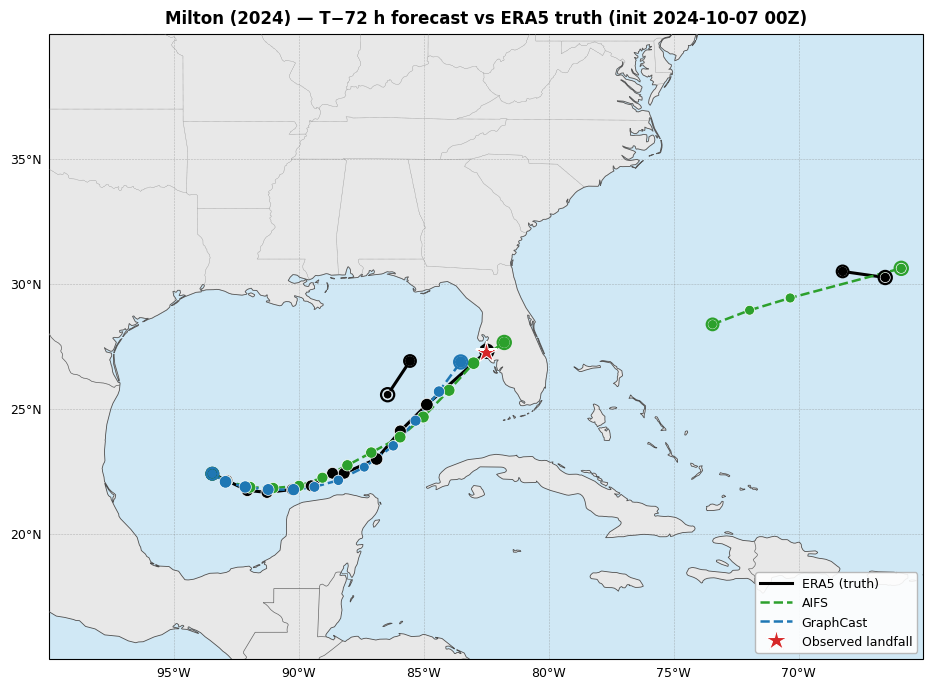

In [24]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_72, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_72, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_72,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−72 h forecast vs ERA5 truth (init {INIT_TIMES[72]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[72],
    nsteps=N_STEPS[72],
    save_path=OUT_DIR / "track_72h.png",
)

In [25]:
df_72 = make_error_table(72, {
    "ERA5 (truth)": era5_tracks_72,
    "AIFS":         aifs_tracks_72,
    "GraphCast":    gc_tracks_72,
})
print(f"\n=== T−72h position error (km) vs ERA5 truth ===\n")
print(df_72.to_string(index=False))


=== T−72h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-07 00Z             0               5764
  10-07 06Z             4               5581
  10-07 12Z            18               5376
  10-07 18Z            33               5177
  10-08 00Z            32               4955
  10-08 06Z            59               4749
  10-08 12Z            70               4532
  10-08 18Z           144               4381
  10-09 00Z           137               4148
  10-09 06Z           112               3945
  10-09 12Z           109               3748
  10-10 00Z            79               3389


saved → outputs/milton/track_168h.png


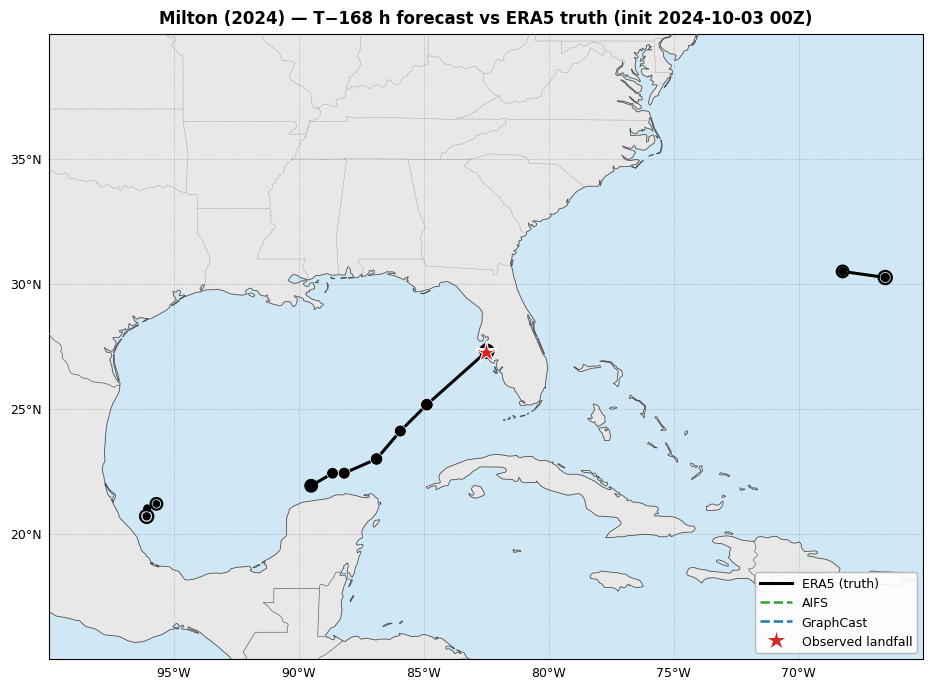

In [26]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_168, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_168, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_168,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−168 h forecast vs ERA5 truth (init {INIT_TIMES[168]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[168],
    nsteps=N_STEPS[168],
    save_path=OUT_DIR / "track_168h.png",
)

In [27]:
df_168 = make_error_table(168, {
    "ERA5 (truth)": era5_tracks_168,
    "AIFS":         aifs_tracks_168,
    "GraphCast":    gc_tracks_168,
})
print(f"\n=== T−168h position error (km) vs ERA5 truth ===\n")
print(df_168.to_string(index=False))


=== T−168h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-08 06Z          1985                 --
  10-08 12Z          2109                 --
  10-08 18Z          2182               1988
  10-09 00Z          2324               2119
  10-09 06Z          2451               2225
  10-09 12Z          2598               2349
  10-10 00Z          2920               2661


saved → outputs/milton/track_240h.png


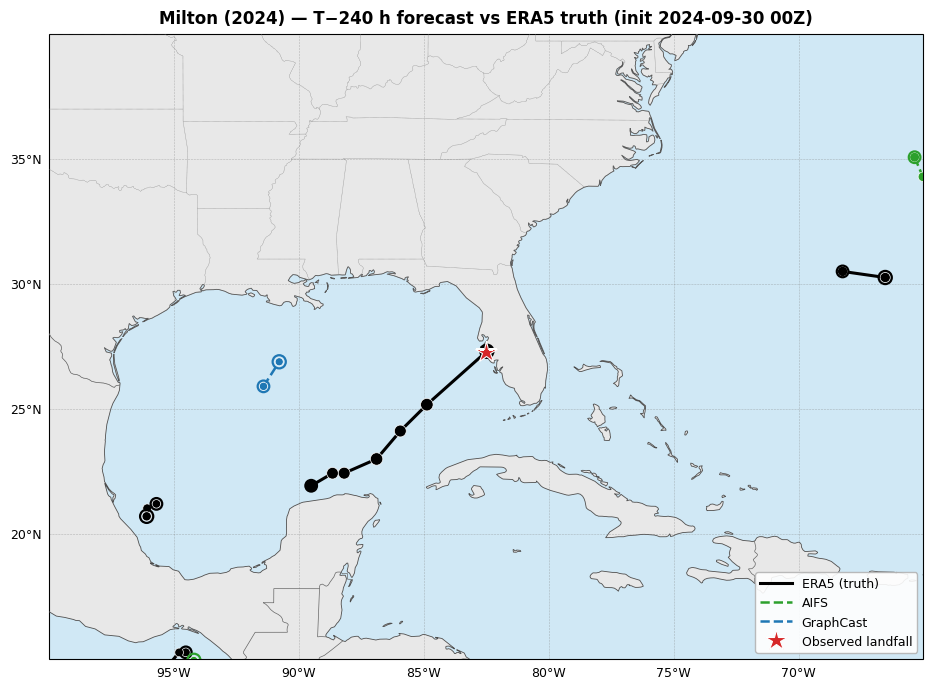

In [28]:
plot_tracks(
    [
        {"name": "ERA5 (truth)", "tracks": era5_tracks_240, "color": MODEL_COLORS["ERA5"]},
        {"name": "AIFS",         "tracks": aifs_tracks_240, "color": MODEL_COLORS["AIFS"]},
        {"name": "GraphCast",    "tracks": gc_tracks_240,   "color": MODEL_COLORS["GraphCast"]},
    ],
    extent=PLOT_EXTENT,
    title=f"{STORM_NAME} (2024) — T−240 h forecast vs ERA5 truth (init {INIT_TIMES[240]:%Y-%m-%d %H}Z)",
    init_time=INIT_TIMES[240],
    nsteps=N_STEPS[240],
    save_path=OUT_DIR / "track_240h.png",
)

In [29]:
df_240 = make_error_table(240, {
    "ERA5 (truth)": era5_tracks_240,
    "AIFS":         aifs_tracks_240,
    "GraphCast":    gc_tracks_240,
})
print(f"\n=== T−240h position error (km) vs ERA5 truth ===\n")
print(df_240.to_string(index=False))


=== T−240h position error (km) vs ERA5 truth ===

Valid (UTC) AIFS err (km) GraphCast err (km)
  10-08 06Z          1923               4305
  10-08 12Z          2025               4107
  10-08 18Z          2084               3930
  10-09 00Z          2216               3682
  10-09 06Z          2329               3474
  10-09 12Z          2448               3273
  10-10 00Z          2725               2882
